# Import necessary libraries

In [1]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# Define the fuzzy variables

In [2]:
# Input variable: Temperature (in degrees Celsius)
temperature = ctrl.Antecedent(np.arange(0, 41, 1), 'temperature')

# Input variable: Humidity (in percentage)
humidity = ctrl.Antecedent(np.arange(0, 101, 1), 'humidity')

# Output variable: Fan Speed (in RPM)
fan_speed = ctrl.Consequent(np.arange(0, 2601, 1), 'fan_speed')

# Define membership functions for each variable

In [3]:
# Membership functions for Temperature
temperature['cold'] = fuzz.trimf(temperature.universe, [0, 0, 15])
temperature['cool'] = fuzz.trimf(temperature.universe, [10, 15, 20])
temperature['warm'] = fuzz.trimf(temperature.universe, [15, 20, 25])
temperature['hot'] = fuzz.trimf(temperature.universe, [20, 30, 40])

In [4]:
# Membership functions for Humidity
humidity['dry'] = fuzz.trimf(humidity.universe, [0, 0, 40])
humidity['comfortable'] = fuzz.trimf(humidity.universe, [30, 50, 70])
humidity['humid'] = fuzz.trimf(humidity.universe, [60, 100, 100])

In [5]:
# Membership functions for Fan Speed
fan_speed['low'] = fuzz.trimf(fan_speed.universe, [0, 0, 1000])
fan_speed['medium'] = fuzz.trimf(fan_speed.universe, [500, 1500, 2000])
fan_speed['high'] = fuzz.trimf(fan_speed.universe, [1500, 2600, 2600])

# Define fuzzy rules

In [6]:
rule1 = ctrl.Rule(temperature['cold'] & humidity['dry'], fan_speed['low'])
rule2 = ctrl.Rule(temperature['cold'] & humidity['comfortable'], fan_speed['low'])
rule3 = ctrl.Rule(temperature['cold'] & humidity['humid'], fan_speed['medium'])
rule4 = ctrl.Rule(temperature['cool'] & humidity['dry'], fan_speed['low'])
rule5 = ctrl.Rule(temperature['cool'] & humidity['comfortable'], fan_speed['medium'])
rule6 = ctrl.Rule(temperature['cool'] & humidity['humid'], fan_speed['medium'])
rule7 = ctrl.Rule(temperature['warm'] & humidity['dry'], fan_speed['medium'])
rule8 = ctrl.Rule(temperature['warm'] & humidity['comfortable'], fan_speed['medium'])
rule9 = ctrl.Rule(temperature['warm'] & humidity['humid'], fan_speed['high'])
rule10 = ctrl.Rule(temperature['hot'] & humidity['dry'], fan_speed['medium'])
rule11 = ctrl.Rule(temperature['hot'] & humidity['comfortable'], fan_speed['high'])
rule12 = ctrl.Rule(temperature['hot'] & humidity['humid'], fan_speed['high'])

# Create and simulate the control system

In [7]:
fan_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9, rule10, rule11, rule12])
fan_simulation = ctrl.ControlSystemSimulation(fan_ctrl)

# Test the system with different inputs

In [8]:
fan_simulation.input['temperature'] = 30  
fan_simulation.input['humidity'] = 70     

In [9]:
fan_simulation.compute()

In [10]:
print(f"Fan Speed: {fan_simulation.output['fan_speed']} RPM")

Fan Speed: 2115.4761904761904 RPM


# Visualize the results

C:\Users\meets\AppData\Local\Programs\Python\Python312\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


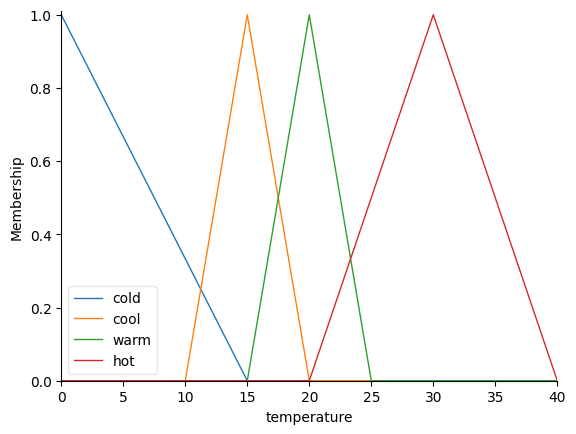

In [11]:
temperature.view()

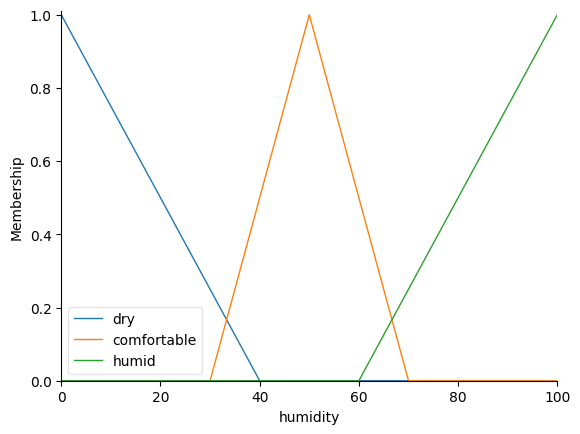

In [12]:
humidity.view()

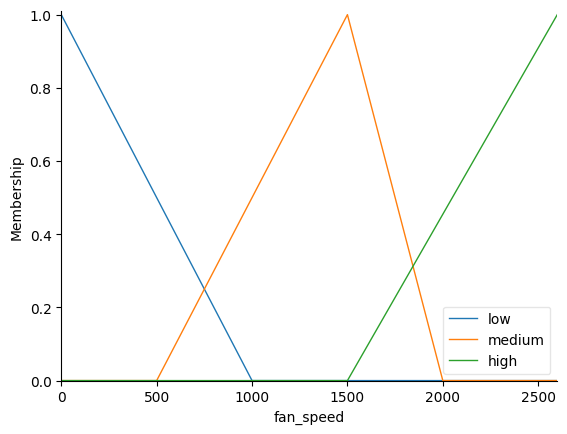

In [13]:
fan_speed.view()

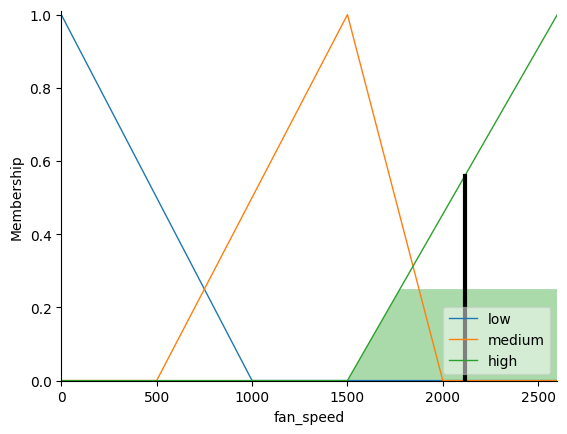

In [14]:
fan_speed.view(sim=fan_simulation)

# Generate a control surface for analysis

In [15]:
temp_range = np.arange(0, 41, 1)
humidity_range = np.arange(0, 101, 1)
temperature_grid, humidity_grid = np.meshgrid(temp_range, humidity_range)
fan_speed_output = np.zeros_like(temperature_grid)

In [16]:
fan_speed_output = np.full_like(temperature_grid, np.nan, dtype=float)

In [17]:
for i in range(len(temp_range)):
    for j in range(len(humidity_range)):
        fan_simulation.input['temperature'] = temp_range[i]
        fan_simulation.input['humidity'] = humidity_range[j]
        fan_simulation.compute()
        try:
            fan_speed_output[j, i] = fan_simulation.output['fan_speed']
        except KeyError:
            fan_speed_output[j, i] = np.nan

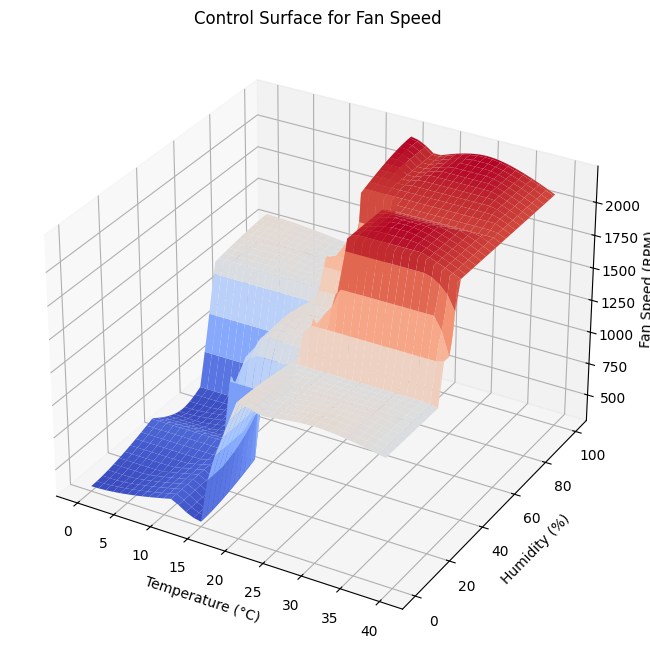

In [18]:
# Plot the control surface
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(temperature_grid, humidity_grid, fan_speed_output, cmap='coolwarm')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Humidity (%)')
ax.set_zlabel('Fan Speed (RPM)')
plt.title('Control Surface for Fan Speed')
plt.show()